# Makine Öğrenmesine Giriş - Mini Proje 2
## Overfitting (Aşırı Öğrenme) Gösterimi: Küçük vs. Büyük Model

**Öğrenci:** Sudenaz Serin  
**Konu:** Bir yapay sinir ağı modelinin kapasitesinin (katman ve nöron sayısının), modelin öğrenme ve genelleme yeteneği üzerindeki etkisinin incelenmesi. Bu projede, TensorFlow'un `tf_flowers` veri seti kullanılarak modellerin veriyi "ezberleme" (Overfitting) ve "öğrenememe" (Underfitting) durumları uygulamalı olarak gösterilecektir.

### 1. Gerekli Kütüphanelerin Yüklenmesi
**Bu hücre ne yapıyor?** Proje boyunca kullanacağımız veri işleme, modelleme ve görselleştirme kütüphanelerini (`TensorFlow`, `NumPy`, `Matplotlib`, `OS`) çalışma ortamına dahil eder.

In [ ]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print(f"TensorFlow Sürümü: {tf.__version__}")

TensorFlow Sürümü: 2.19.0


### 2. Veri Setinin İndirilmesi ve Ön İşleme (Data Preprocessing)
**Bu hücre ne yapıyor?** Google'ın açık kaynaklı çiçek veri setini (5 farklı sınıf: Papatya, Karahindiba, Gül, Ayçiçeği, Lale) indirir. Veriyi modelin daha hızlı işleyebilmesi için %80 Eğitim (Train) ve %20 Doğrulama (Validation) olarak ikiye böler. İşlem süresini kısaltmak için görseller **64x64 piksel** boyutuna getirilir.

In [ ]:
print("Veri seti hazırlanıyor...")
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

# Klasör yolunu garantiye alma (Tek sınıf hatasını önlemek için)
if os.path.exists(os.path.join(data_dir, 'flower_photos')):
    data_dir = os.path.join(data_dir, 'flower_photos')
data_dir = pathlib.Path(data_dir)

# Modelin hızlı eğitilmesi için görsel boyutları 64x64 olarak belirlenmiştir.
batch_size = 32
img_height = 64
img_width = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(f"\nBaşarıyla Yüklenen Çiçek Sınıfları: {class_names}")

# CPU/GPU darboğazını önlemek için önbelleğe alma işlemleri
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Veri seti hazırlanıyor...
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.

Başarıyla Yüklenen Çiçek Sınıfları: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Veri Setinden Örnek Görseller
**Bu hücre ne yapıyor?** Eğitim veri setinden rastgele 10 adet çiçek görselini alır ve sınıflarıyla (etiketleriyle) birlikte ekrana yazdırır. Görsellerin hafif bulanık (pikselli) olmasının sebebi, modellerin daha hızlı eğitilebilmesi için boyutlarının 64x64 piksel olarak ayarlanmış olmasıdır.

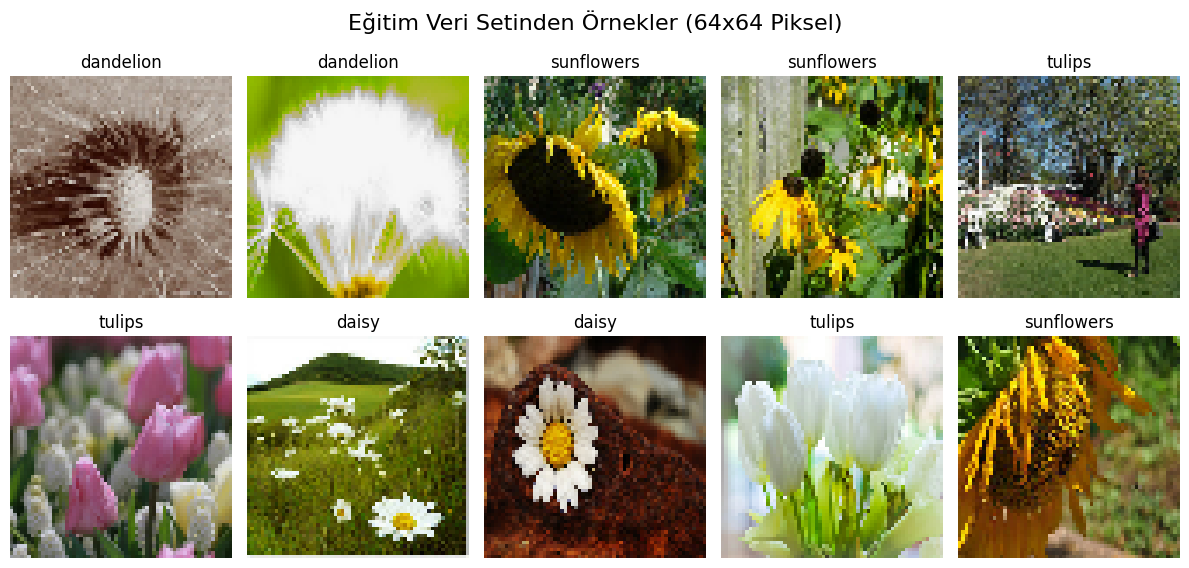

In [ ]:
# Veri setinden bir paket (batch) alıp ilk 10 görseli çizdiriyoruz
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
  for i in range(10):
    ax = plt.subplot(2, 5, i + 1) # 2 satır, 5 sütunluk bir tablo
    plt.imshow(images[i].numpy().astype("uint8"))
    # Sınıf adını başlık olarak ekle
    plt.title(class_names[labels[i]])
    plt.axis("off") # Eksen çizgilerini gizle

plt.suptitle("Eğitim Veri Setinden Örnekler (64x64 Piksel)", fontsize=16)
plt.tight_layout()
plt.show()

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


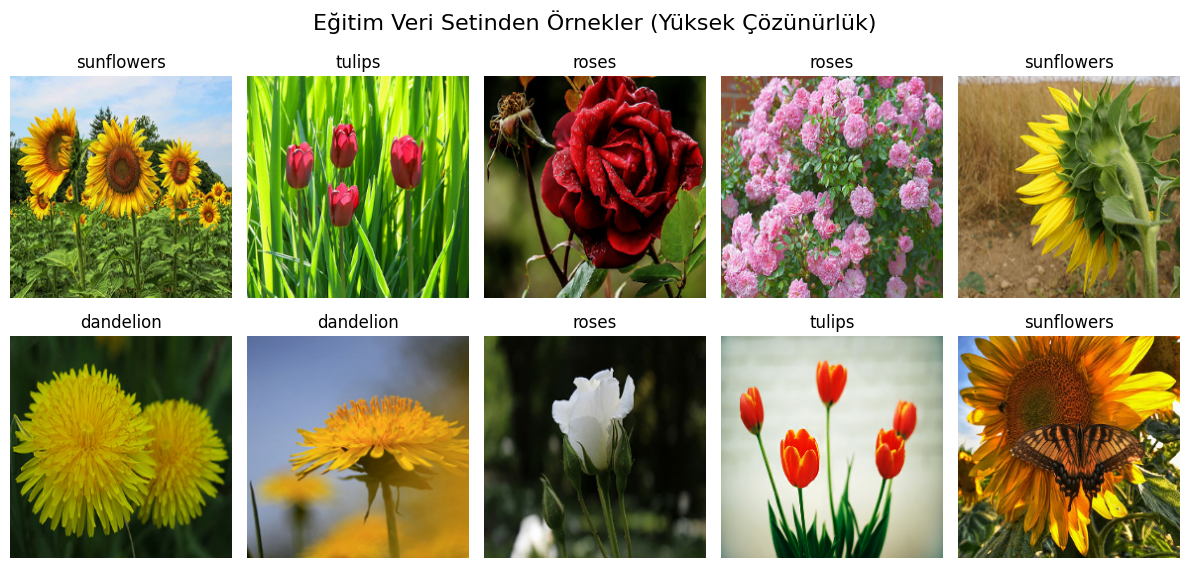

In [ ]:
# Bu hücre SADECE sunumda kullanılacak net görselleri elde etmek içindir.
# Ana modellerimizin (64x64) eğitimini etkilemez.

# Veriyi geçici olarak yüksek çözünürlükle (224x224) yüklüyoruz
temp_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(224, 224), # Cam gibi net olması için boyutu büyüttük!
  batch_size=10)

plt.figure(figsize=(12, 6))
for images, labels in temp_ds.take(1):
  for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.suptitle("Eğitim Veri Setinden Örnekler (Yüksek Çözünürlük)", fontsize=16)
plt.tight_layout()
plt.show()

### 3. Küçük Modelin Tasarımı (Underfitting / Düşük Kapasite)
**Bu hücre ne yapıyor?** Çok sınırlı öğrenme kapasitesine sahip "Küçük" bir model inşa eder. Sadece 1 gizli katman ve 16 nörondan oluşur.
**Beklentimiz:** Model kapasitesi çok düşük olduğu için bu karmaşık görsellerin örüntülerini yakalamakta zorlanacak ve başarı oranı düşük kalacaktır.

In [ ]:
small_model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)), # Piksel değerlerini 0-1 arasına çekme
  layers.Flatten(),
  layers.Dense(16, activation='relu'), # Çok düşük nöron sayısı
  layers.Dense(5) # 5 farklı çiçek sınıfı için çıkış katmanı
], name="Kucuk_Model")

small_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
small_model.summary()

Model: "Kucuk_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │       196,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,709 (768.39 KB)

 Trainable params: 196,709 (768.39 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Büyük Modelin Tasarımı (Overfitting / Ezberleme)
**Bu hücre ne yapıyor?** Gereğinden fazla parametreye sahip "Büyük" bir model inşa eder. İçerisinde 512 nöronlu iki devasa gizli katman bulunur.
**Beklentimiz:** Model, eğitim verisindeki görsellerin genel özelliklerini (yaprak yapısı, renk) öğrenmek yerine, fotoğraflardaki pikselleri ve arka plan gürültülerini *ezberleyecektir*. Bu durum, modelin hiç görmediği doğrulama (validation) verisinde başarısız olmasına (Overfitting) yol açacaktır.

In [ ]:
large_model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Flatten(),
  layers.Dense(512, activation='relu'), # Aşırı yüksek nöron sayısı
  layers.Dense(512, activation='relu'),
  layers.Dense(5)
], name="Buyuk_Model")

large_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
large_model.summary()

Model: "Buyuk_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,189 (25.01 MB)

 Trainable params: 6,557,189 (25.01 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Modellerin Eğitimi ve Sonuçların Değerlendirilmesi
**Bu hücre ne yapıyor?** Hazırlanan her iki modeli de aynı veri seti üzerinde 15 Epoch (eğitim döngüsü) boyunca eğitir ve sonuçları grafiksel olarak ekrana yazdırır.

*Mini Projenin Çıktı Analizi:*
Grafikler incelendiğinde; Büyük Model'in **Eğitim Kaybı (Train Loss)** sıfıra doğru hızla düşerken, **Doğrulama Kaybının (Val Loss)** bir süre sonra artışa geçtiği ve çizgilerin birbirinden koptuğu görülecektir. Bu durum **Overfitting'in (Aşırı Öğrenme)** kesin bir ispatıdır.


 Kucuk_Model EĞİTİMİ BAŞLIYOR 
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.2214 - loss: 1.7848 - val_accuracy: 0.2398 - val_loss: 1.6075
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2459 - loss: 1.6063 - val_accuracy: 0.2398 - val_loss: 1.6057
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2459 - loss: 1.6043 - val_accuracy: 0.2398 - val_loss: 1.6041
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2459 - loss: 1.6027 - val_accuracy: 0.2398 - val_loss: 1.6032
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2459 - loss: 1.6017 - val_accuracy: 0.2398 - val_loss: 1.6026
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2459 - loss: 1.6011 - val_accuracy: 0.2398 - val_loss: 1.6022
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2459 - loss: 1.6006 - val_accuracy: 0.2398 - val_loss: 1.6019
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2459 - loss: 1.600

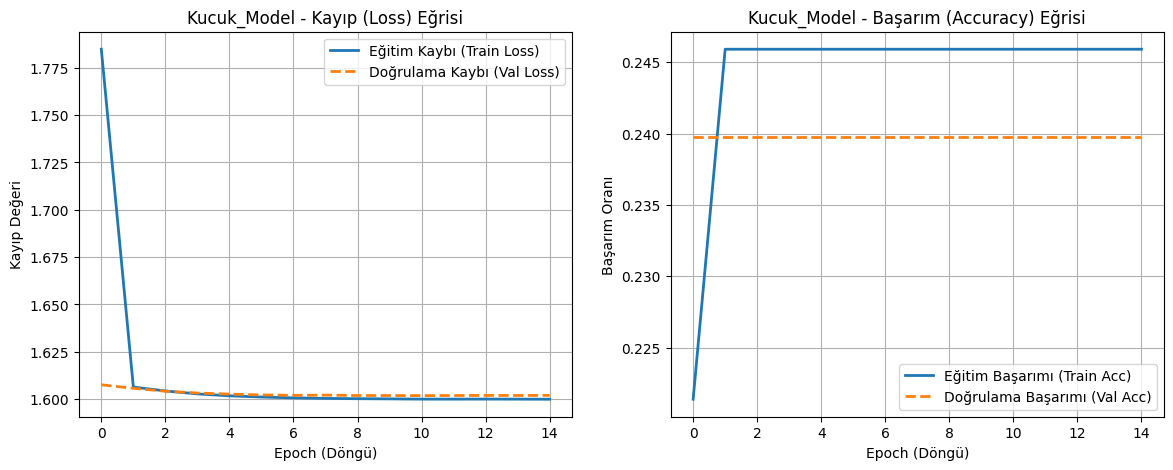


 Buyuk_Model EĞİTİMİ BAŞLIYOR 
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.3583 - loss: 2.1830 - val_accuracy: 0.4809 - val_loss: 1.2732
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.4527 - loss: 1.2728 - val_accuracy: 0.4441 - val_loss: 1.2916
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.4813 - loss: 1.2095 - val_accuracy: 0.4605 - val_loss: 1.2520
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.4956 - loss: 1.2031 - val_accuracy: 0.4482 - val_loss: 1.3069
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.5031 - loss: 1.1656 - val_accuracy: 0.4959 - val_loss: 1.2226
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.5252 - loss: 1.1288 - val_accuracy: 0.4659 - val_loss: 1.2930
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.5766 - loss: 1.0500 - val_accuracy: 0.5259 - val_loss: 1.2509
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.5896 - loss

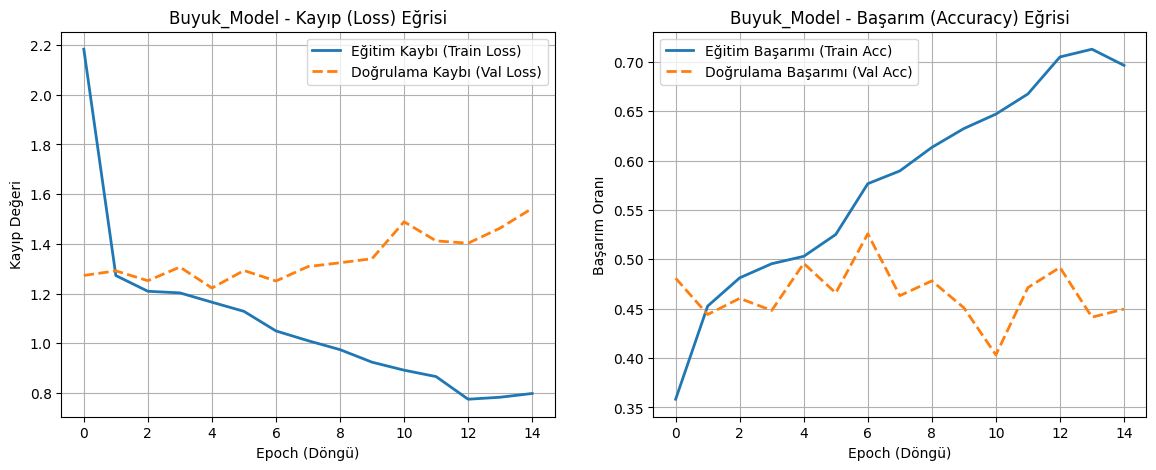

In [ ]:
def train_and_plot(model, epochs=15):
    print(f"\n{'='*40}")
    print(f" {model.name} EĞİTİMİ BAŞLIYOR ")
    print(f"{'='*40}")

    history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=epochs,
      verbose=1
    )

    # Grafik Çizimleri
    plt.figure(figsize=(14, 5))

    # 1. Kayıp (Loss) Grafiği
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Eğitim Kaybı (Train Loss)', linewidth=2)
    plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Val Loss)', linewidth=2, linestyle='--')
    plt.title(f'{model.name} - Kayıp (Loss) Eğrisi')
    plt.xlabel('Epoch (Döngü)')
    plt.ylabel('Kayıp Değeri')
    plt.legend()
    plt.grid(True)

    # 2. Başarım (Accuracy) Grafiği
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Eğitim Başarımı (Train Acc)', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Doğrulama Başarımı (Val Acc)', linewidth=2, linestyle='--')
    plt.title(f'{model.name} - Başarım (Accuracy) Eğrisi')
    plt.xlabel('Epoch (Döngü)')
    plt.ylabel('Başarım Oranı')
    plt.legend()
    plt.grid(True)

    plt.show()

# Eğitimi Başlat (Boyutlar 64x64 olduğu için çok kısa sürecektir)
train_and_plot(small_model, epochs=15)
train_and_plot(large_model, epochs=15)